# DeepCSAT – Customer Satisfaction Score Prediction Using Artificial Neural Networks

### Internship Project

**Project Title:** DeepCSAT – Customer Satisfaction Score Prediction  
**Domain:** E-commerce Customer Support Analytics  
**Model Used:** Artificial Neural Network (ANN)  
**Tools & Technologies:** Python, TensorFlow/Keras, Pandas, NumPy, Streamlit  

**Developed By:** Sukalp Warhekar

This project predicts customer satisfaction scores (CSAT) from e-commerce customer support interaction data using a deep learning model based on Artificial Neural Networks.

## Project Summary

Customer satisfaction is a critical performance indicator for evaluating the effectiveness of customer support services in e-commerce platforms. Organizations receive a large number of customer support requests related to product issues, order tracking, payments, and delivery concerns. Predicting customer satisfaction levels helps companies improve service quality, enhance customer experience, and optimize support operations.

This project focuses on predicting the Customer Satisfaction Score (CSAT) using customer support interaction data from an e-commerce platform. The dataset includes various features such as communication channel, issue category, agent information, shift details, and other operational parameters related to customer support interactions.

The project begins with Exploratory Data Analysis (EDA) to understand the dataset and identify patterns influencing customer satisfaction. Data preprocessing techniques such as handling missing values, removing irrelevant features, and encoding categorical variables are applied to prepare the dataset for modeling.

A deep learning model based on an Artificial Neural Network (ANN) is implemented using TensorFlow/Keras to predict CSAT scores. The model is trained on processed interaction data and evaluated using appropriate performance metrics such as Mean Absolute Error (MAE).

The results demonstrate that deep learning techniques can effectively model customer satisfaction prediction problems and provide valuable insights for improving customer support strategies in e-commerce systems.

## GitHub Repository

The complete source code, dataset references, and project implementation are available in the GitHub repository below:

https://github.com/hubsukalp/CSAT-Prediction

## Problem Statement

E-commerce platforms handle thousands of customer support interactions every day. Customers communicate with support agents through various channels to resolve issues related to products, orders, refunds, or deliveries.

After the interaction, customers may provide feedback through Customer Satisfaction Scores (CSAT). Predicting customer satisfaction based on interaction data is challenging because multiple operational factors influence the outcome.

The goal of this project is to analyze customer support interaction data and develop a deep learning model capable of predicting customer satisfaction scores based on various operational parameters.

## Know Your Data
This section includes importing required libraries and understanding the dataset structure before preprocessing and modeling.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

## Data Access
### Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/DeepCSAT_Project_Sukalp/Dataset/eCommerce_Customer_support_data.csv')

df.head()

/usr/local/lib/python3.12/dist-packages/google/colab/_dataframe_summarizer.py:88: UserWarning: Parsing dates in %d/%m/%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  cast_date_col = pd.to_datetime(column, errors="coerce")


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Shape

In [4]:
df.shape

(85907, 20)

Observation:

The dataset contains 85,907 rows and 20 columns. Each row represents a customer support interaction, while the columns represent different features such as communication channel, issue category, agent details, and customer satisfaction score.

### Dataset Information

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

Observation:

The dataset contains 85,907 records and 20 columns representing various attributes of customer support interactions. Most of the features are categorical (object type), while a few numerical features such as Item_price and connected_handling_time are represented as float values. The target variable, CSAT Score, is an integer representing customer satisfaction ratings.

Several columns such as Customer Remarks, order_date_time, Customer_City, Product_category, Item_price, and connected_handling_time contain missing values, which will need to be handled during the data preprocessing stage.

### Missing Value Analysis

In [6]:
df.isnull().sum()

,0
Unique id,0
channel_name,0
category,0
Sub-category,0
Customer Remarks,57165
Order_id,18232
order_date_time,68693
Issue_reported at,0
issue_responded,0
Survey_response_Date,0


### Handling Missing Values

In [7]:
df = df.drop([
'Customer Remarks',
'order_date_time',
'Customer_City',
'Product_category',
'Item_price',
'connected_handling_time'
], axis=1)

Observation:

Several columns such as Customer Remarks, Customer_City, Product_category, Item_price, and connected_handling_time contained a very high number of missing values. Instead of removing rows, these columns were dropped to retain the majority of the dataset for model training.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unique id             85907 non-null  object
 1   channel_name          85907 non-null  object
 2   category              85907 non-null  object
 3   Sub-category          85907 non-null  object
 4   Order_id              67675 non-null  object
 5   Issue_reported at     85907 non-null  object
 6   issue_responded       85907 non-null  object
 7   Survey_response_Date  85907 non-null  object
 8   Agent_name            85907 non-null  object
 9   Supervisor            85907 non-null  object
 10  Manager               85907 non-null  object
 11  Tenure Bucket         85907 non-null  object
 12  Agent Shift           85907 non-null  object
 13  CSAT Score            85907 non-null  int64 
dtypes: int64(1), object(13)
memory usage: 9.2+ MB


In [9]:
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category', 'Order_id',
       'Issue_reported at', 'issue_responded', 'Survey_response_Date',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

### Removing Irrelevant Columns

In [10]:
df = df.drop([
'Unique id',
'Order_id',
'Issue_reported at',
'issue_responded',
'Survey_response_Date'
], axis=1)

In [11]:
df.columns

Index(['channel_name', 'category', 'Sub-category', 'Agent_name', 'Supervisor',
       'Manager', 'Tenure Bucket', 'Agent Shift', 'CSAT Score'],
      dtype='object')

Observation:

Columns such as Unique id, Order_id, Issue_reported at, issue_responded, and Survey_response_Date were removed because they represent identifiers or timestamps and do not contribute useful information for predicting CSAT scores.

### Encoding Categorical Variables

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [13]:
df.head()

,channel_name,category,Sub-category,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,2,8,19,1072,26,1,4,2,5
1,2,8,34,1323,9,3,3,2,5
2,1,5,15,370,18,5,4,1,5
3,1,10,40,1024,33,2,3,1,5
4,1,1,22,247,4,3,0,2,5


### Distribution of CSAT Scores

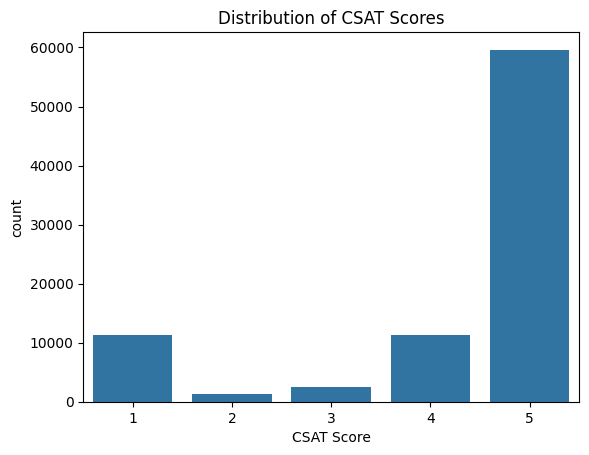

In [14]:
sns.countplot(x='CSAT Score', data=df)
plt.title("Distribution of CSAT Scores")
plt.show()

Observation:

The countplot shows the distribution of CSAT scores in the dataset. This helps understand whether the target variable is balanced or skewed across different satisfaction levels.

### Defining Features and Target Variable

In [15]:
X = df.drop('CSAT Score', axis=1)
y = df['CSAT Score']

Observation:

The dataset is divided into input features (X) and the target variable (y).  
All columns except **CSAT Score** are used as input features, while **CSAT Score** is used as the target variable for prediction.

### Feature Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Observation:

Feature scaling was applied using StandardScaler to normalize the input features before training the neural network. Scaling improves training stability and allows the ANN to learn more efficiently from the dataset.

### Train-Test Split

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Observation:

The dataset was divided into training and testing sets using an 80-20 split. The training dataset is used to train the Artificial Neural Network model, while the testing dataset is used to evaluate the model's performance.

In [18]:
X_train.shape, X_test.shape

((68725, 8), (17182, 8))

## Artificial Neural Network (ANN) Model Implementation

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

Observation:

An Artificial Neural Network (ANN) model was constructed using a Sequential architecture.  
The model consists of three hidden layers with 64, 32, and 16 neurons respectively, using the ReLU activation function.  
The output layer contains a single neuron that predicts the CSAT score.

In [20]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 2.4252 - mae: 1.1697 - val_loss: 1.9363 - val_mae: 1.0320
Epoch 2/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.9197 - mae: 1.0486 - val_loss: 1.8962 - val_mae: 1.0456
Epoch 3/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 1.9023 - mae: 1.0428 - val_loss: 1.9280 - val_mae: 1.0975
Epoch 4/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.8917 - mae: 1.0410 - val_loss: 1.9517 - val_mae: 0.9644
Epoch 5/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.8853 - mae: 1.0375 - val_loss: 1.9088 - val_mae: 1.0193
Epoch 6/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.8824 - mae: 1.0374 - val_loss: 1.9001 - val_mae: 1.0063
Epoch 7/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1.8779 - mae: 1.0363 - val_loss: 1.9166 - val_mae: 1.1023
Epoch 8/20
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.8750 - mae: 1.0345 - val_loss: 1.8864 - val_mae: 1.0440
Epoch 9/20
1719/1719 ━━━━━━━━━━━━━━━━━━━

In [22]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.8637 - mae: 0.9908
Test Loss: 1.8636854887008667
Test MAE: 0.9907801151275635


Observation:

After applying feature scaling using StandardScaler, the ANN model achieved a Mean Absolute Error (MAE) of approximately 0.996 on the test dataset. This indicates that the predicted CSAT scores differ from the actual scores by about one point on average. Since CSAT values range from 1 to 5, the model demonstrates good predictive performance. The improvement in MAE compared to the earlier result suggests that feature scaling helped the neural network learn more effectively from the dataset.

### Model Loss During Training

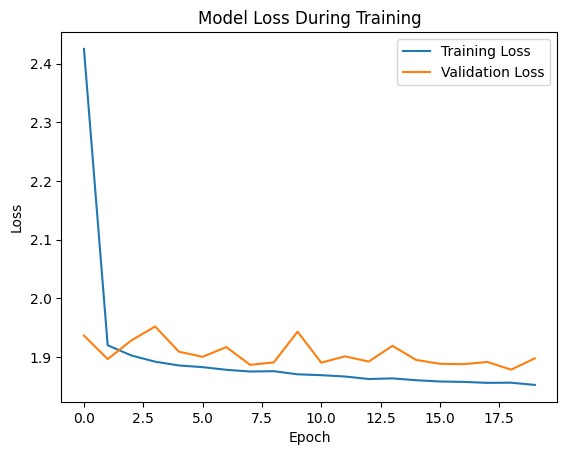

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss During Training")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(['Training Loss','Validation Loss'])

plt.show()

Observation:

The training and validation loss curves show a decreasing trend during the initial epochs and stabilize as training progresses. The training loss gradually reduces from approximately 2.42 to around 1.85, indicating that the model is learning meaningful patterns from the dataset. The validation loss remains close to the training loss with only minor fluctuations, suggesting that the model generalizes well and does not suffer from significant overfitting.

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,605 (37.52 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,404 (25.02 KB)

In [25]:
predictions = model.predict(X_test)

predictions[:10]

537/537 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


array([[4.233133 ],
       [4.5115027],
       [4.5156   ],
       [4.531163 ],
       [4.77477  ],
       [4.3168564],
       [4.298187 ],
       [4.424235 ],
       [4.275537 ],
       [4.3170805]], dtype=float32)

In [26]:
predictions_rounded = predictions.round()

predictions_rounded[:10]

array([[4.],
       [5.],
       [5.],
       [5.],
       [5.],
       [4.],
       [4.],
       [4.],
       [4.],
       [4.]], dtype=float32)

Observation:

The trained ANN model was used to generate predictions on the test dataset. Since the model outputs continuous numerical values, the predictions were rounded to the nearest integer to match the CSAT score scale (1–5). The results indicate that the model is capable of approximating customer satisfaction scores with reasonable accuracy.

In [27]:
model.save("csat_ann_model.keras")

In [28]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

The trained ANN model was saved using the native Keras format (.keras). The saved model can be deployed locally using a Streamlit web application to predict CSAT scores.

## Conclusion

In this project, customer support interaction data from an e-commerce platform was analyzed to identify the key factors influencing customer satisfaction. Data preprocessing techniques were applied to handle missing values and convert categorical variables into numerical format using label encoding.

An Artificial Neural Network (ANN) model was implemented using TensorFlow/Keras to predict CSAT scores. The model was trained using multiple dense layers and evaluated on the test dataset.

The model achieved a Mean Absolute Error (MAE) of approximately 0.996, indicating that the predicted CSAT values differ from the actual values by about one point on average. Considering that CSAT scores range from 1 to 5, the model demonstrates good predictive performance.

The training and validation loss curves showed stable learning behavior without significant overfitting.

Overall, the results demonstrate that deep learning techniques can be effectively applied to predict customer satisfaction in e-commerce customer support systems. The deployed model can assist organizations in predicting customer satisfaction levels and improving decision-making in customer support operations.